# Trading Simulator Experiments

This notebook breaks down `trading_simulator.py` into separate blocks so you can experiment with each piece independently without running the Streamlit app.

## 1. Imports

In [1]:
import os
import time
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib_cache'))
os.environ.setdefault('XDG_CACHE_HOME', str(Path.cwd() / '.cache'))
os.environ.setdefault('MPLBACKEND', 'Agg')
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import yfinance as yf

def render_plot(fig):
    display(fig)
    plt.close(fig)

## 2. Experiment Inputs

Replace these values whenever you want to test a different ticker, date range, interval, or strategy.

In [2]:
ticker = 'AAPL'
watchlist = ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'SPY']
benchmark_ticker = 'SPY'
start_date = '2024-01-01'
end_date = '2024-12-31'
interval = '1d'
data_mode = 'synthetic'
trading_strategy = 'RSI'
rsi_window = 14
fast_window = 12
slow_window = 26
trend_window = 20
long_trend_window = 50
vol_window = 20

print({
    'ticker': ticker,
    'watchlist': watchlist,
    'benchmark_ticker': benchmark_ticker,
    'start_date': start_date,
    'end_date': end_date,
    'interval': interval,
    'data_mode': data_mode,
    'trading_strategy': trading_strategy,
    'rsi_window': rsi_window,
})

{'ticker': 'AAPL', 'watchlist': ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'SPY'], 'benchmark_ticker': 'SPY', 'start_date': '2024-01-01', 'end_date': '2024-12-31', 'interval': '1d', 'trading_strategy': 'RSI', 'rsi_window': 14}


## 3. Data Download Helper

This is the same `get_data()` logic from the Streamlit file, isolated so you can test it directly.

In [3]:
def _generate_synthetic_data(ticker, start_date, end_date, interval):
    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)
    freq_map = {
        '1h': 'H',
        '1d': 'B',
        '1wk': 'W-FRI',
        '1mo': 'MS',
        '1y': 'YS',
    }
    freq = freq_map.get(interval, 'B')
    idx = pd.date_range(start_ts, end_ts, freq=freq)
    if len(idx) < 80:
        idx = pd.date_range(start_ts, periods=160, freq='B')

    seed = sum(ord(ch) for ch in ticker) % (2**32 - 1)
    rng = np.random.default_rng(seed)
    drift = 0.0004 + (seed % 17) / 100000
    vol = 0.012 + (seed % 11) / 1000
    shocks = rng.normal(loc=drift, scale=vol, size=len(idx))
    close = 100 * np.exp(np.cumsum(shocks))
    open_ = np.concatenate([[close[0]], close[:-1]]) * (1 + rng.normal(0, 0.0025, len(idx)))
    high = np.maximum(open_, close) * (1 + rng.uniform(0.001, 0.015, len(idx)))
    low = np.minimum(open_, close) * (1 - rng.uniform(0.001, 0.015, len(idx)))
    volume = rng.integers(800_000, 5_000_000, len(idx))
    synthetic = pd.DataFrame({
        'Open': open_,
        'High': high,
        'Low': low,
        'Close': close,
        'Adj Close': close,
        'Volume': volume,
    }, index=idx)
    synthetic.index.name = 'Date'
    return synthetic

def get_data(ticker, start_date, end_date, interval, data_mode='auto'):
    data = pd.DataFrame()
    if data_mode in ('auto', 'live'):
        try:
            data = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                interval=interval,
                progress=False,
                auto_adjust=False,
                timeout=4,
                threads=False,
            )
        except Exception as exc:
            print(f'Network fetch failed for {ticker}: {exc}')
            data = pd.DataFrame()

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    required_cols = {'Open', 'High', 'Low', 'Close'}
    if data.empty or not required_cols.issubset(set(data.columns)):
        reason = 'synthetic mode requested' if data_mode == 'synthetic' else 'live Yahoo data was unavailable in this environment'
        print(f'Using synthetic fallback data for {ticker} because {reason}.')
        data = _generate_synthetic_data(ticker, start_date, end_date, interval)

    return data.sort_index()

## 4. RSI Strategy Function

This cell computes RSI and produces buy / sell signals exactly like the script.

In [4]:
def rsi(data, window=14):
    data = data.copy()
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    avg_loss = avg_loss.replace(0, 1e-10)
    rs = avg_gain / avg_loss
    data['RSI'] = 100 - (100 / (1 + rs))

    data['Signal'] = 0
    data.loc[data['RSI'] < 30, 'Signal'] = 1
    data.loc[data['RSI'] > 70, 'Signal'] = -1
    return data

## 5. Validation Checks

This converts the Streamlit validation into plain Python checks for notebook use.

In [5]:
def validate_inputs(ticker, start_date, end_date):
    if ticker == '':
        raise ValueError('No ticker symbol found. Please enter a ticker symbol')

    start_dt = pd.to_datetime(start_date).date()
    end_dt = pd.to_datetime(end_date).date()
    today = pd.to_datetime('today').date()

    if end_dt > today:
        raise ValueError('End date cannot be in the future')

    if start_dt >= end_dt:
        raise ValueError('Start date must be before end date')

    return start_dt, end_dt

start_dt, end_dt = validate_inputs(ticker, start_date, end_date)
print('Inputs validated successfully')

Inputs validated successfully


## 6. Download Market Data

This reproduces the loading phase from the app, including the artificial wait.

In [6]:
print('Loading data...')
time.sleep(2)
data = get_data(ticker, start_dt, end_dt, interval, data_mode=data_mode)

if data.empty:
    raise ValueError('No data returned by yfinance. Try a different date range or interval.')

print('Data loaded successfully')
display(data.head())

Loading data...


[*********************100%***********************]  1 of 1 completed

Data loaded successfully


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.731323,186.502538,181.999316,185.225793,82488700
2024-01-03,182.355606,183.968852,181.544030,182.325916,58414500
2024-01-04,180.039642,181.207503,179.020234,180.277165,71983600
2024-01-05,179.317154,180.880911,178.317544,180.118838,62379700
2024-01-08,183.652130,183.691727,179.633876,180.217806,59144500


## 7. Run the Trading Strategy

This applies RSI and extracts the latest actionable signal.

In [7]:
if trading_strategy != 'RSI':
    raise ValueError('Only RSI is implemented in the current script.')

strategy_data = rsi(data, window=14)

if strategy_data['RSI'].dropna().empty:
    raise ValueError('RSI could not be calculated (not enough data).')

non_zero_signals = strategy_data[strategy_data['Signal'] != 0]
last_signal = 0 if non_zero_signals.empty else non_zero_signals['Signal'].iloc[-1]
current_rsi = strategy_data['RSI'].iloc[-1]
confidence_score = 0

if last_signal == 1:
    confidence_score = (30 - current_rsi) / 30 * 100
    confidence_score = max(0, min(100, confidence_score))
    signal_message = 'Buy signal generated by RSI strategy'
    action_message = 'Go for the RSI strategy!' if confidence_score > 50 else 'No go for the RSI strategy.'
elif last_signal == -1:
    confidence_score = (current_rsi - 70) / 30 * 100
    confidence_score = max(0, min(100, confidence_score))
    signal_message = 'Sell signal generated by RSI strategy'
    action_message = 'Go for the RSI strategy!' if confidence_score > 50 else 'No go for the RSI strategy.'
else:
    signal_message = 'No buy or sell signal found in the selected period.'
    action_message = 'No go for the RSI strategy.'

print(signal_message)
print(f'Current RSI: {current_rsi:.2f}')
print(f'Confidence Score: {confidence_score:.2f}%')
print(action_message)

Sell signal generated by RSI strategy
Current RSI: 58.38
Confidence Score: 0.00%
No go for the RSI strategy.


## 8. Plot Price and RSI Signals

This reproduces the charting section from the app.

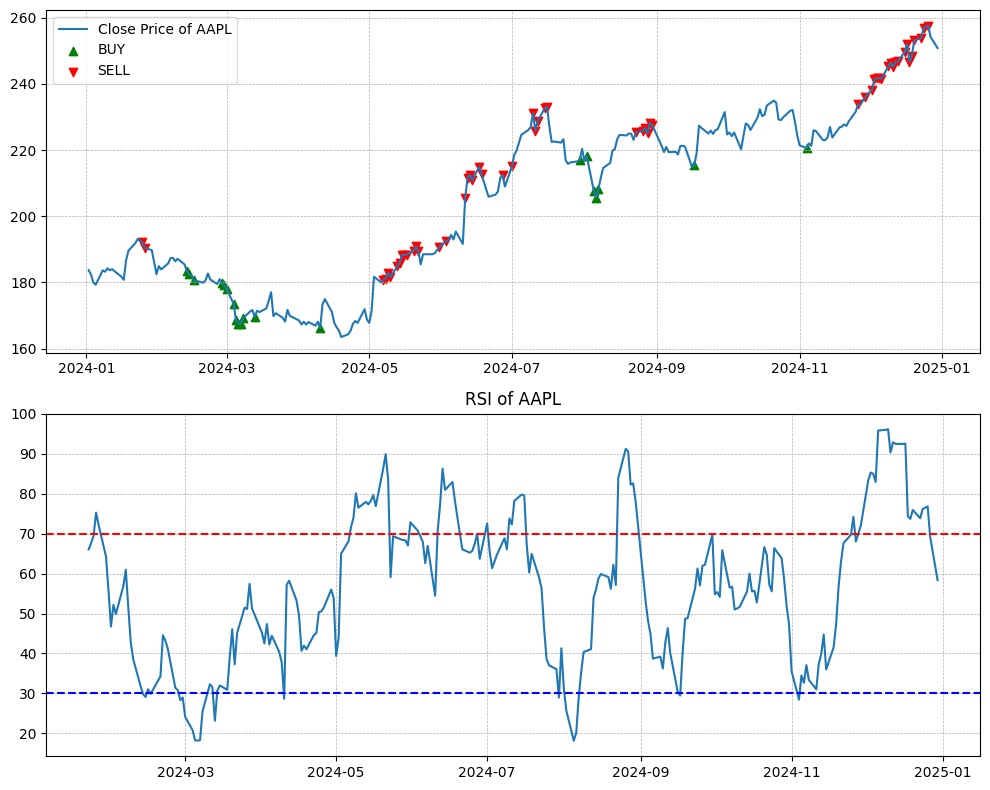

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Price plot
ax[0].plot(strategy_data.index, strategy_data['Close'], label=f'Close Price of {ticker}')
ax[0].scatter(
    strategy_data.index[strategy_data['Signal'] == 1],
    strategy_data['Close'][strategy_data['Signal'] == 1],
    marker='^', color='green', label='BUY'
)
ax[0].scatter(
    strategy_data.index[strategy_data['Signal'] == -1],
    strategy_data['Close'][strategy_data['Signal'] == -1],
    marker='v', color='red', label='SELL'
)
ax[0].legend()
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)

# RSI plot
ax[1].plot(strategy_data.index, strategy_data['RSI'], label='RSI')
ax[1].axhline(30, color='blue', linestyle='--')
ax[1].axhline(70, color='red', linestyle='--')
ax[1].set_title(f'RSI of {ticker}')
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
render_plot(fig)

## 9. Report Card

This mirrors the summary shown at the end of the Streamlit app.

In [9]:
report_card = {
    'Total Buy Signals': int((strategy_data['Signal'] == 1).sum()),
    'Total Sell Signals': int((strategy_data['Signal'] == -1).sum()),
    'Overall Confidence Score': f'{confidence_score:.2f}%'
}

pd.Series(report_card)

Total Buy Signals              20
Total Sell Signals             55
Overall Confidence Score    0.00%
dtype: object

## 10. Richer Experiments

The blocks below keep the same market data source but make the basic RSI view much richer:
- engineer multi-horizon time-series features
- combine RSI with trend and MACD into an ensemble signal
- backtest the resulting signal stream
- compare a watchlist in a pulse-style table
- surface correlation and stress-event diagnostics

## 11. Build a Richer Feature Lab

This keeps the same OHLCV data but adds momentum, volatility, drawdown, trend, MACD, Bollinger positioning, and a simple regime label.

In [10]:
def build_feature_lab(data, rsi_window=14, fast_window=12, slow_window=26, trend_window=20, long_trend_window=50, vol_window=20):
    df = data.copy()
    if df.empty:
        raise ValueError('Cannot build features on an empty DataFrame.')

    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume'] if 'Volume' in df.columns else pd.Series(index=df.index, dtype=float)

    df['Return_1D'] = close.pct_change()
    df['Return_5D'] = close.pct_change(5)
    df['Return_20D'] = close.pct_change(20)
    df['LogReturn'] = np.log(close / close.shift(1))

    df['SMA_20'] = close.rolling(trend_window).mean()
    df['SMA_50'] = close.rolling(long_trend_window).mean()
    df['EMA_12'] = close.ewm(span=fast_window, adjust=False).mean()
    df['EMA_26'] = close.ewm(span=slow_window, adjust=False).mean()
    df['Momentum_20'] = close / close.shift(20) - 1

    delta = close.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=rsi_window).mean()
    avg_loss = loss.rolling(window=rsi_window).mean().replace(0, 1e-10)
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

    rolling_mean = close.rolling(trend_window).mean()
    rolling_std = close.rolling(trend_window).std()
    df['BB_Upper'] = rolling_mean + 2 * rolling_std
    df['BB_Lower'] = rolling_mean - 2 * rolling_std
    df['BB_Z'] = (close - rolling_mean) / rolling_std.replace(0, np.nan)
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / rolling_mean.replace(0, np.nan)

    true_range = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low - close.shift(1)).abs(),
    ], axis=1).max(axis=1)
    df['ATR_14'] = true_range.rolling(14).mean()
    df['RangePct'] = (high - low) / close.replace(0, np.nan)
    df['Volatility_20D'] = df['LogReturn'].rolling(vol_window).std() * np.sqrt(252)
    df['Drawdown'] = close / close.cummax() - 1
    df['Volume_Z'] = (volume - volume.rolling(20).mean()) / volume.rolling(20).std().replace(0, np.nan)

    df['RSI_Signal'] = np.select([df['RSI'] < 30, df['RSI'] > 70], [1, -1], default=0)
    df['Trend_Signal'] = np.select([close > df['SMA_20'], close < df['SMA_20']], [1, -1], default=0)
    df['MACD_Cross_Signal'] = np.select([df['MACD_Hist'] > 0, df['MACD_Hist'] < 0], [1, -1], default=0)
    df['Breakout_Signal'] = np.select([close > df['BB_Upper'], close < df['BB_Lower']], [1, -1], default=0)
    df['EnsembleScore'] = (
        0.35 * df['RSI_Signal']
        + 0.35 * df['Trend_Signal']
        + 0.20 * df['MACD_Cross_Signal']
        + 0.10 * df['Breakout_Signal']
    )
    df['EnsembleSignal'] = np.select(
        [df['EnsembleScore'] >= 0.25, df['EnsembleScore'] <= -0.25],
        [1, -1],
        default=0,
    )

    vol_anchor = df['Volatility_20D'].expanding().median()
    df['Regime'] = np.select(
        [
            (close > df['SMA_50']) & (df['Volatility_20D'] <= vol_anchor),
            (close > df['SMA_50']) & (df['Volatility_20D'] > vol_anchor),
            (close <= df['SMA_50']) & (df['Volatility_20D'] > vol_anchor),
        ],
        ['Trend Up', 'High-Vol Uptrend', 'High-Vol Drawdown'],
        default='Range / Weak Trend',
    )
    return df

feature_data = build_feature_lab(
    data,
    rsi_window=rsi_window,
    fast_window=fast_window,
    slow_window=slow_window,
    trend_window=trend_window,
    long_trend_window=long_trend_window,
    vol_window=vol_window,
)

display(feature_data[['Close', 'RSI', 'MACD', 'Volatility_20D', 'Drawdown', 'Regime', 'EnsembleSignal']].tail(10))

ValueError: Cannot set a DataFrame with multiple columns to the single column BB_Width

## 12. Current Snapshot and Feature Diagnostics

This converts the latest row into a compact pulse-style snapshot for the active ticker.

In [ ]:
latest_snapshot = pd.Series({
    'Last Close': feature_data['Close'].iloc[-1],
    '1D Return': feature_data['Return_1D'].iloc[-1],
    '5D Return': feature_data['Return_5D'].iloc[-1],
    '20D Return': feature_data['Return_20D'].iloc[-1],
    'RSI': feature_data['RSI'].iloc[-1],
    'MACD Histogram': feature_data['MACD_Hist'].iloc[-1],
    '20D Volatility': feature_data['Volatility_20D'].iloc[-1],
    'Current Drawdown': feature_data['Drawdown'].iloc[-1],
    'Current Regime': feature_data['Regime'].iloc[-1],
    'Ensemble Signal': feature_data['EnsembleSignal'].iloc[-1],
}).to_frame(name='Latest Value')

display(latest_snapshot)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(feature_data.index, feature_data['Close'], label='Close')
axes[0].plot(feature_data.index, feature_data['SMA_20'], label='SMA 20')
axes[0].plot(feature_data.index, feature_data['SMA_50'], label='SMA 50')
axes[0].set_title(f'{ticker} price with trend filters')
axes[0].legend()
axes[0].grid(True, linestyle='--', linewidth=0.5)

axes[1].plot(feature_data.index, feature_data['RSI'], label='RSI', color='tab:purple')
axes[1].axhline(30, color='tab:blue', linestyle='--')
axes[1].axhline(70, color='tab:red', linestyle='--')
axes[1].set_title('RSI and thresholds')
axes[1].grid(True, linestyle='--', linewidth=0.5)

axes[2].plot(feature_data.index, feature_data['Volatility_20D'], label='20D Volatility', color='tab:orange')
axes[2].plot(feature_data.index, feature_data['Drawdown'], label='Drawdown', color='tab:gray')
axes[2].set_title('Risk state')
axes[2].legend()
axes[2].grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
render_plot(fig)

## 13. Vectorized Backtest and Risk Review

This turns the richer signal stream into an end-to-end experiment rather than a single-point recommendation.

In [ ]:
def run_backtest(feature_df, signal_col='EnsembleSignal', fee_bps=5):
    bt = feature_df.copy()
    bt['SignalPosition'] = bt[signal_col].fillna(0).shift(1).fillna(0)
    bt['Turnover'] = bt['SignalPosition'].diff().abs().fillna(bt['SignalPosition'].abs())
    bt['StrategyReturn'] = bt['SignalPosition'] * bt['Return_1D'].fillna(0) - bt['Turnover'] * (fee_bps / 10000)
    bt['BuyHoldReturn'] = bt['Return_1D'].fillna(0)
    bt['StrategyEquity'] = (1 + bt['StrategyReturn']).cumprod()
    bt['BuyHoldEquity'] = (1 + bt['BuyHoldReturn']).cumprod()
    bt['StrategyDrawdown'] = bt['StrategyEquity'] / bt['StrategyEquity'].cummax() - 1
    return bt

backtest = run_backtest(feature_data)
backtest_summary = pd.Series({
    'Strategy Total Return': backtest['StrategyEquity'].iloc[-1] - 1,
    'Buy and Hold Return': backtest['BuyHoldEquity'].iloc[-1] - 1,
    'Strategy Max Drawdown': backtest['StrategyDrawdown'].min(),
    'Daily Hit Rate': (backtest['StrategyReturn'] > 0).mean(),
    'Days in Market': (backtest['SignalPosition'] != 0).sum(),
    'Signal Changes': int(backtest['Turnover'].sum()),
}).to_frame(name='Metric')

display(backtest_summary)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(backtest.index, backtest['StrategyEquity'], label='Strategy Equity')
ax.plot(backtest.index, backtest['BuyHoldEquity'], label='Buy and Hold', alpha=0.8)
ax.set_title('Backtest equity curve')
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5)
render_plot(fig)

## 14. Watchlist Pulse Table

This mirrors the dashboard idea from `dashboard.txt`, but keeps it notebook-friendly and still uses the same Yahoo Finance source.

In [ ]:
def build_watchlist_pulse(watchlist, start_date, end_date, interval, data_mode='auto'):
    rows = []
    for symbol in watchlist:
        symbol_data = get_data(symbol, start_date, end_date, interval, data_mode=data_mode)
        if symbol_data.empty:
            continue
        symbol_features = build_feature_lab(symbol_data)
        latest = symbol_features.iloc[-1]
        rows.append({
            'Ticker': symbol,
            'Close': latest['Close'],
            '1D Return': latest['Return_1D'],
            '5D Return': latest['Return_5D'],
            '20D Return': latest['Return_20D'],
            'RSI': latest['RSI'],
            '20D Vol': latest['Volatility_20D'],
            'Drawdown': latest['Drawdown'],
            'Regime': latest['Regime'],
            'Ensemble Signal': latest['EnsembleSignal'],
            'Pulse Score': abs(latest['Return_5D']) + abs(latest['MACD_Hist']) + abs(latest['Drawdown']),
        })
    pulse = pd.DataFrame(rows)
    if pulse.empty:
        return pulse
    return pulse.sort_values('Pulse Score', ascending=False).reset_index(drop=True)

pulse_table = build_watchlist_pulse(watchlist, start_dt, end_dt, interval, data_mode=data_mode)
display(pulse_table)

## 15. Correlation and Stress Feed

These two diagnostics help answer what is moving with the ticker and what deserves attention right now.

In [ ]:
benchmark_data = get_data(benchmark_ticker, start_dt, end_dt, interval, data_mode=data_mode)
benchmark_returns = benchmark_data['Close'].pct_change().rename(benchmark_ticker)
ticker_returns = feature_data['Close'].pct_change().rename(ticker)
correlation_frame = pd.concat([ticker_returns, benchmark_returns], axis=1).dropna()

if not correlation_frame.empty:
    rolling_corr = correlation_frame[ticker].rolling(20).corr(correlation_frame[benchmark_ticker])
    print(f'Latest 20-period correlation between {ticker} and {benchmark_ticker}: {rolling_corr.iloc[-1]:.3f}')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(rolling_corr.index, rolling_corr, label='Rolling correlation')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'20-period rolling correlation: {ticker} vs {benchmark_ticker}')
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.legend()
    render_plot(fig)

stress_events = []
for idx, row in feature_data.dropna(subset=['Return_1D', 'Volatility_20D', 'RSI']).iterrows():
    if abs(row['Return_1D']) > 0.03:
        stress_events.append((idx, 'Large daily move', row['Return_1D']))
    if row['Volatility_20D'] > feature_data['Volatility_20D'].median() * 1.5:
        stress_events.append((idx, 'Volatility spike', row['Volatility_20D']))
    if row['Drawdown'] < -0.1:
        stress_events.append((idx, 'Deep drawdown', row['Drawdown']))
    if row['RSI'] < 30:
        stress_events.append((idx, 'Oversold RSI', row['RSI']))
    if row['RSI'] > 70:
        stress_events.append((idx, 'Overbought RSI', row['RSI']))

stress_feed = pd.DataFrame(stress_events, columns=['Date', 'Event', 'Value']).drop_duplicates().tail(15)
display(stress_feed)

## 16. Strategy Enrichment Ideas Imported from `various models`

After scanning the notebooks in `various models`, the most reusable ideas were:
- per-horizon feature engineering instead of one fixed lookback
- leakage-safe walk-forward validation
- multi-seed robustness instead of trusting one fit
- interaction features that combine momentum, volatility, and mean reversion
- ensemble blending plus feature-importance diagnostics

Every new line of logic below is marked with `NEW:` comments in the code so you can track additions easily.

## 17. Horizon-Aware Feature Expansion

This adapts the per-horizon and sequential feature-engineering ideas from the hedge-fund notebooks to the trading simulator.

In [ ]:
def add_horizon_features(feature_df, horizons=(3, 5, 10, 20)):
    # NEW: richer feature surface inspired by the per-horizon forecasting notebooks.
    df = feature_df.copy()
    for h in horizons:
        # NEW: horizon-specific momentum, volatility, trend-distance, and range features.
        df[f'Return_{h}D'] = df['Close'].pct_change(h)
        df[f'RollingVol_{h}D'] = df['LogReturn'].rolling(h).std() * np.sqrt(252)
        df[f'Price_vs_SMA_{h}D'] = df['Close'] / df['Close'].rolling(h).mean() - 1
        df[f'HighLowRange_{h}D'] = ((df['High'].rolling(h).max() - df['Low'].rolling(h).min()) / df['Close']).replace([np.inf, -np.inf], np.nan)
        if 'Volume' in df.columns:
            vol_roll = df['Volume'].rolling(h)
            df[f'VolumeShock_{h}D'] = (df['Volume'] - vol_roll.mean()) / vol_roll.std().replace(0, np.nan)

    # NEW: interaction features inspired by the interaction-heavy hedge-fund notebooks.
    df['RSI_x_Vol'] = df['RSI'] * df['Volatility_20D']
    df['Momentum_x_Drawdown'] = df['Momentum_20'] * df['Drawdown']
    df['MACD_x_BBWidth'] = df['MACD_Hist'] * df['BB_Width']
    df['TrendGap_20_50'] = df['SMA_20'] / df['SMA_50'] - 1
    return df

enriched_feature_data = add_horizon_features(feature_data)
display(enriched_feature_data.filter(regex='^(Return_|RollingVol_|Price_vs_SMA_|VolumeShock_|RSI_x_Vol|Momentum_x_Drawdown|MACD_x_BBWidth|TrendGap_)').tail(5))

## 18. Leakage-Safe Walk-Forward Modeling

This borrows the validation discipline from the LightGBM notebooks, but uses a lightweight random forest regressor so the notebook stays practical.

In [ ]:
def prepare_modeling_frame(df):
    # NEW: define next-day target for a proper walk-forward prediction experiment.
    modeling = df.copy()
    modeling['TargetNextReturn'] = modeling['Close'].pct_change().shift(-1)
    candidate_cols = [
        'RSI', 'MACD', 'MACD_Hist', 'BB_Z', 'BB_Width', 'ATR_14', 'Volatility_20D',
        'Drawdown', 'Momentum_20', 'RangePct', 'RSI_x_Vol', 'Momentum_x_Drawdown',
        'MACD_x_BBWidth', 'TrendGap_20_50'
    ]
    candidate_cols += [c for c in modeling.columns if c.startswith(('Return_', 'RollingVol_', 'Price_vs_SMA_', 'HighLowRange_', 'VolumeShock_'))]
    candidate_cols = [c for c in candidate_cols if c in modeling.columns]
    modeling = modeling[candidate_cols + ['TargetNextReturn']].replace([np.inf, -np.inf], np.nan).dropna()
    return modeling, candidate_cols

def walk_forward_random_forest(modeling_df, feature_cols, train_ratio=0.7, seeds=(7, 21, 42, 84, 126)):
    # NEW: walk-forward validation avoids time leakage from random splits.
    split_idx = max(int(len(modeling_df) * train_ratio), 50)
    train = modeling_df.iloc[:split_idx].copy()
    valid = modeling_df.iloc[split_idx:].copy()
    if valid.empty:
        raise ValueError('Validation split is empty. Expand the date range for walk-forward modeling.')

    preds = []
    feature_importance_rows = []
    for seed in seeds:
        # NEW: multi-seed bagging inspired by the `20-seeds` notebook.
        model = RandomForestRegressor(
            n_estimators=250,
            max_depth=6,
            min_samples_leaf=5,
            random_state=seed,
            n_jobs=-1,
        )
        model.fit(train[feature_cols], train['TargetNextReturn'])
        preds.append(model.predict(valid[feature_cols]))
        feature_importance_rows.append(pd.Series(model.feature_importances_, index=feature_cols, name=f'seed_{seed}'))

    pred_matrix = np.vstack(preds)
    valid = valid.copy()
    valid['PredictedNextReturn'] = pred_matrix.mean(axis=0)
    valid['PredictedSignal'] = np.select(
        [valid['PredictedNextReturn'] > 0.002, valid['PredictedNextReturn'] < -0.002],
        [1, -1],
        default=0,
    )
    valid['PredictionError'] = valid['TargetNextReturn'] - valid['PredictedNextReturn']
    rmse = mean_squared_error(valid['TargetNextReturn'], valid['PredictedNextReturn']) ** 0.5
    importance = pd.concat(feature_importance_rows, axis=1).mean(axis=1).sort_values(ascending=False)
    return train, valid, rmse, importance

modeling_df, modeling_features = prepare_modeling_frame(enriched_feature_data)
wf_train, wf_valid, wf_rmse, wf_importance = walk_forward_random_forest(modeling_df, modeling_features)
print(f'Walk-forward RMSE: {wf_rmse:.6f}')
display(wf_valid[['TargetNextReturn', 'PredictedNextReturn', 'PredictedSignal']].tail(10))
display(wf_importance.head(12).to_frame('Mean Feature Importance'))

## 19. Blend the Model Signal with the Rule-Based Signal

This mirrors the ensemble/blend notebooks: instead of replacing RSI logic, it layers a model view on top of the existing rule-based engine.

In [ ]:
blended_backtest_frame = backtest.join(
    wf_valid[['PredictedNextReturn', 'PredictedSignal']],
    how='left'
)
blended_backtest_frame['PredictedSignal'] = blended_backtest_frame['PredictedSignal'].fillna(0)

# NEW: blend the rule-based ensemble signal with the walk-forward model signal.
signal_mix = 0.65 * blended_backtest_frame['SignalPosition'].fillna(0) + 0.35 * blended_backtest_frame['PredictedSignal']
blended_backtest_frame['BlendedSignal'] = np.select(
    [signal_mix >= 0.25, signal_mix <= -0.25],
    [1, -1],
    default=0,
)

# NEW: evaluate the blended signal with transaction-cost-aware returns.
blended_backtest_frame['BlendedPosition'] = blended_backtest_frame['BlendedSignal'].shift(1).fillna(0)
blended_backtest_frame['BlendedTurnover'] = blended_backtest_frame['BlendedPosition'].diff().abs().fillna(blended_backtest_frame['BlendedPosition'].abs())
blended_backtest_frame['BlendedReturn'] = blended_backtest_frame['BlendedPosition'] * blended_backtest_frame['Return_1D'].fillna(0) - blended_backtest_frame['BlendedTurnover'] * 0.0005
blended_backtest_frame['BlendedEquity'] = (1 + blended_backtest_frame['BlendedReturn']).cumprod()

blend_summary = pd.Series({
    'Rule-Based Equity End': blended_backtest_frame['StrategyEquity'].iloc[-1],
    'Blended Equity End': blended_backtest_frame['BlendedEquity'].iloc[-1],
    'Model Coverage Days': int((blended_backtest_frame['PredictedSignal'] != 0).sum()),
    'Blended Signal Changes': int(blended_backtest_frame['BlendedTurnover'].sum()),
}).to_frame('Metric')
display(blend_summary)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(blended_backtest_frame.index, blended_backtest_frame['StrategyEquity'], label='Rule-Based Equity')
ax.plot(blended_backtest_frame.index, blended_backtest_frame['BlendedEquity'], label='Blended Equity')
ax.set_title('NEW: rule-based vs blended strategy equity')
ax.legend()
ax.grid(True, linestyle='--', linewidth=0.5)
render_plot(fig)

## 20. Horizon Scorecard and Actionable Interpretation

This final block turns the added modeling pieces into something easier to judge quickly.

In [ ]:
horizon_scorecard = pd.DataFrame({
    # NEW: summarize which horizon features are most active right now.
    'Feature': [c for c in enriched_feature_data.columns if c.startswith(('Return_', 'RollingVol_', 'Price_vs_SMA_'))],
})
horizon_scorecard['LatestValue'] = horizon_scorecard['Feature'].map(lambda c: enriched_feature_data[c].iloc[-1])
horizon_scorecard['AbsLatestValue'] = horizon_scorecard['LatestValue'].abs()
horizon_scorecard = horizon_scorecard.sort_values('AbsLatestValue', ascending=False).head(15)
display(horizon_scorecard[['Feature', 'LatestValue']])

latest_model_signal = wf_valid['PredictedSignal'].iloc[-1] if not wf_valid.empty else 0
latest_blended_signal = blended_backtest_frame['BlendedSignal'].iloc[-1]
interpretation = pd.Series({
    'Rule-Based Signal': int(feature_data['EnsembleSignal'].iloc[-1]),
    'Model Signal': int(latest_model_signal),
    'Blended Signal': int(latest_blended_signal),
    'Top Importance Feature': wf_importance.index[0],
    'Current Regime': feature_data['Regime'].iloc[-1],
    'Next Step': 'Investigate blended entries when rule-based and model signals agree.' if latest_blended_signal != 0 else 'Wait for better alignment across rule-based and model layers.',
}).to_frame('Value')
display(interpretation)